In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import DDM, RDM, CDM

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Metas

In [13]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau", "decay"]
num_obs = 200
num_configs = 6
num_regressors = 4
p_free = 0.5

### Priors

In [14]:
# Priors: intercept vs slope samplers per intrinsic
priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

### Context Manager

In [15]:
cm = ContextManager()  # not used in full-regression path

family = NestedModelFamily(
    name="DDM",
    model=DDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=intrinsic_params,
)

In [16]:
#statically pad the design matrix with 0 to shape (num_obs, max_num_regressors)
# Create a regressor_mask array of shape (max_num_regressors ) mask indicating which column is pad or real
# add a flag to sample function keep_intercept=False which drops the column of 1s from the padded design_matrix

In [17]:
# adapter class
# Does:
# - dtype conversion
# - Ensures everything is at least 2d
# - concatenates nested data outputs into a matrix

In [32]:
out = family.sample(
    num_obs=num_obs,
    num_regressors=10,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a", "tau"},
        intercept_only_intrinsics={"s_tau", "s_v", "decay"},
    )
)
out

Design config not provided. Generating random param mask and design config.
shape of param mask: (40, 6)
[1 0 1 1 1 1 0 1 1 0]
shape of design_matrix: (200, 40)
[0 1 0 0 1 1 1 1 1 0]
shape of design mat: (200, 40)
shape of param mat: (40, 6)


{'model_name': 'DDM',
 'design_config': {'u_0': ['v', 'a', 'tau'],
  'u_1': ['v', 'a', 'tau'],
  'u_2': ['v', 'a', 'tau'],
  'u_3': ['v', 'a', 'tau'],
  'u_4': ['v', 'a', 'tau'],
  'u_5': ['v', 'a', 'tau'],
  'u_6': ['v', 'a', 'tau'],
  'u_7': ['v', 'a', 'tau'],
  'u_8': ['v', 'a', 'tau'],
  'u_9': ['v', 'a', 'tau']},
 'design_matrix': array([[0.9466799 , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.4357152 , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.4094207 , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.54521006, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.30970392, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.53867954, 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(200, 40), dtype=float32),
 'param_mask': array([[1., 1., 1., 0., 0

In [33]:
for k, v in family.collate(family.batch_sample(4)).items():
    print(k, v.shape if hasattr(v, "shape") else len(v))

Design config not provided. Generating random param mask and design config.
shape of param mask: (40, 6)
[0 0 1]
shape of design_matrix: (176, 12)
[0 1 0]
shape of design mat: (176, 12)
shape of param mat: (40, 6)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 40 is different from 12)

In [162]:
intercepts = out["param_samples"].get("_intercepts", {})
print("Intercepts:", {k: round(v, 4) for k, v in intercepts.items()})

Intercepts: {}


In [163]:
rts = sim_data["rts"]
choices = sim_data["choices"]
print("Simulated RTs:", np.nanmin(rts[rts>0]), "→", np.nanmax(rts))
print("Choice rate (mean):", np.mean(choices))

Simulated RTs: 0.452842 → 1.5113276
Choice rate (mean): 1.0


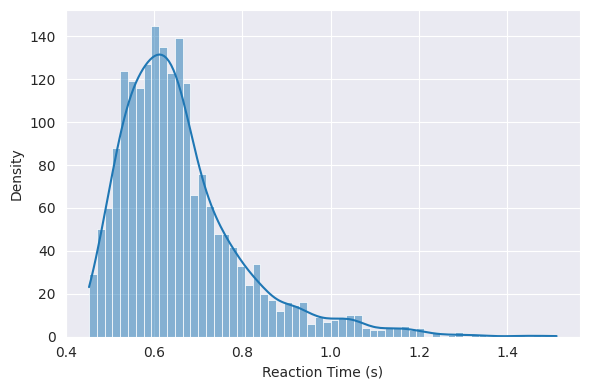

In [164]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(rts[rts > 0], bins=60, kde=True, ax=ax)
ax.set_xlabel("Reaction Time (s)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### Testing multiple batches

In [417]:
runs = []
for k in range(num_configs):
    res = family.sample(
        num_regressors=10,
        mask_randomizer_kwargs=dict(
            mandatory_intrinsics={"v", "a", "tau"},
            intercept_only_intrinsics={"s_tau", "s_v", "decay"},
        ),
    )
    runs.append(res)

[0 0 1 0 1 0 0 1 1 0]
[0 1 0 0 0 1 1 1 0 0]
[0 0 0 0 0 1 1 1 0 0]
[1 0 1 0 1 1 1 0 1 0]
[0 1 1 0 0 1 0 0 0 1]
[1 1 1 0 1 0 1 0 0 1]


In [418]:
def check_run(res):
    dm, pm = res["design_matrix"], res["param_matrix"]
    assert dm.shape == (num_obs, num_regressors)
    rts = res["sim_trials"]["rts"]; choices = res["sim_trials"]["choices"]
    assert rts.shape == (num_obs,) and choices.shape == (num_obs,)
    assert np.isfinite(rts).all()  # if timeouts exist they’ll be -1.0; adjust if you want to allow them
    return rts

all_rts = [check_run(r) for r in runs]
print(f"OK: ran {len(runs)} configs × {num_obs} trials with AUTO full-regression.")

AssertionError: 

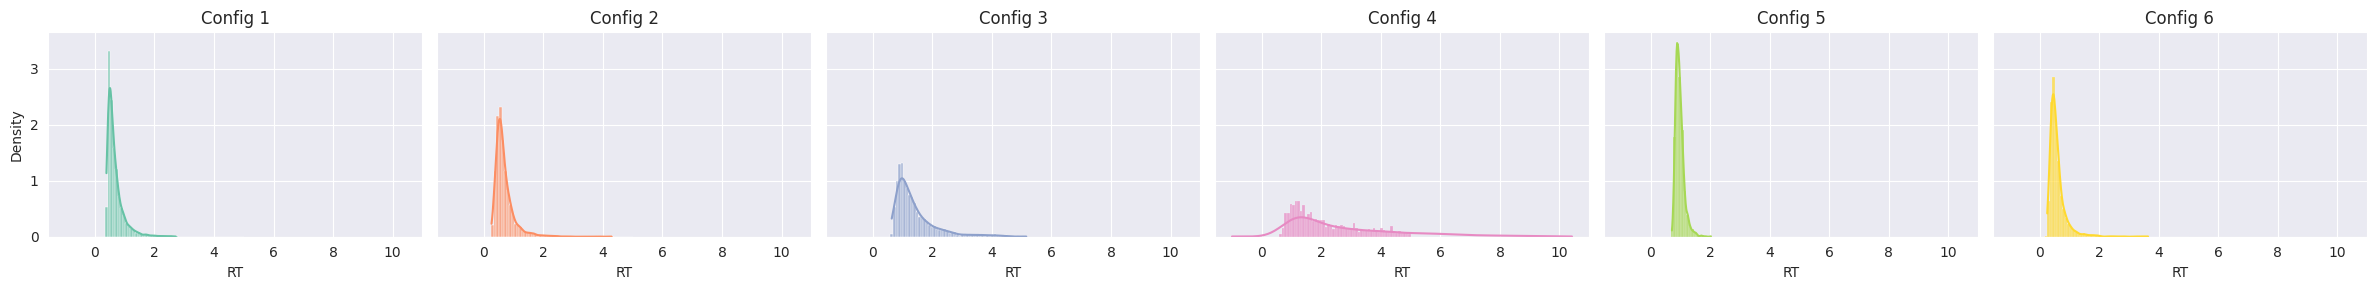

In [419]:
fig, axes = plt.subplots(1, num_configs, figsize=(4*num_configs, 3), sharex=True, sharey=True)
bins = np.linspace(0.0, 5.0, 60)
palette = sns.color_palette("Set2", n_colors=num_configs)

for ax, rts, idx in zip(np.atleast_1d(axes), all_rts, range(num_configs)):
    sns.histplot(rts, bins=bins, stat="density", kde=True, color=palette[idx], alpha=0.7, ax=ax)
    ax.set_title(f"Config {idx+1}")
    ax.set_xlabel("RT")
    ax.set_ylabel("Density")

plt.tight_layout()

### Batch sampling

In [422]:
samples = family.batch_sample(
    batch_size=6,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a", "tau", "s_tau", "s_v"},
        intercept_only_intrinsics={"decay"},
    ),
    min_num_obs=1000,
    max_num_obs=5000
)

[0 1 1 1 0 0 0 0 1 1]
[0 0 0 1 0 1 1 0 0 0]
[1 1 0 1 1 1 0 0 1 1]
[0 0 0 0 1 0 1 1 1 0]
[1 1 0 0 0 1 1 1 0 0]
[0 1 0 1 0 1 0 0 0 0]


In [423]:
samples

[{'model_name': 'DDM',
  'design_config': {'u_0': ['v', 'a', 'tau'],
   'u_1': ['a'],
   'u_2': ['a', 's_tau'],
   'u_3': ['v', 'tau', 's_v'],
   'u_4': ['v', 'a', 'tau'],
   'u_5': ['v', 'a', 'tau', 's_v'],
   'u_6': ['tau'],
   'u_7': ['v', 'tau', 's_v', 's_tau'],
   'u_8': ['v', 'a', 'tau', 's_v', 's_tau'],
   'u_9': []},
  'design_matrix': array([[0.87140614, 1.        , 1.        , ..., 0.6891269 , 0.        ,
          1.        ],
         [0.8979165 , 1.        , 1.        , ..., 0.5726425 , 0.        ,
          1.        ],
         [0.47674748, 0.        , 1.        , ..., 0.524664  , 0.        ,
          0.        ],
         ...,
         [0.39020962, 0.        , 0.        , ..., 0.5644002 , 1.        ,
          1.        ],
         [0.5154615 , 1.        , 1.        , ..., 0.74078214, 0.        ,
          1.        ],
         [0.259097  , 1.        , 0.        , ..., 0.54888844, 0.        ,
          0.        ]], shape=(1973, 10), dtype=float32),
  'param_mask': arr

In [427]:
samples[0]['sim_trials']['rts'].shape

(1973,)

In [439]:
p = np.ones(6) / 6
samples = np.random.multinomial(1, p, size=10)
samples[:, :5].shape

(10, 5)

In [443]:
a = np.zeros((5, 5))
a

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [446]:
b = np.ones((5, 3))
b

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [455]:
a = np.delete(a, 2, axis=1)
a

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [456]:
a = np.insert(a, [2], b, axis=1)
a

array([[0., 0., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 1., 0., 0.]])

In [457]:
a[:, 6]

array([0., 0., 0., 0., 0.])

AttributeError: 'numpy.ndarray' object has no attribute 'insert'

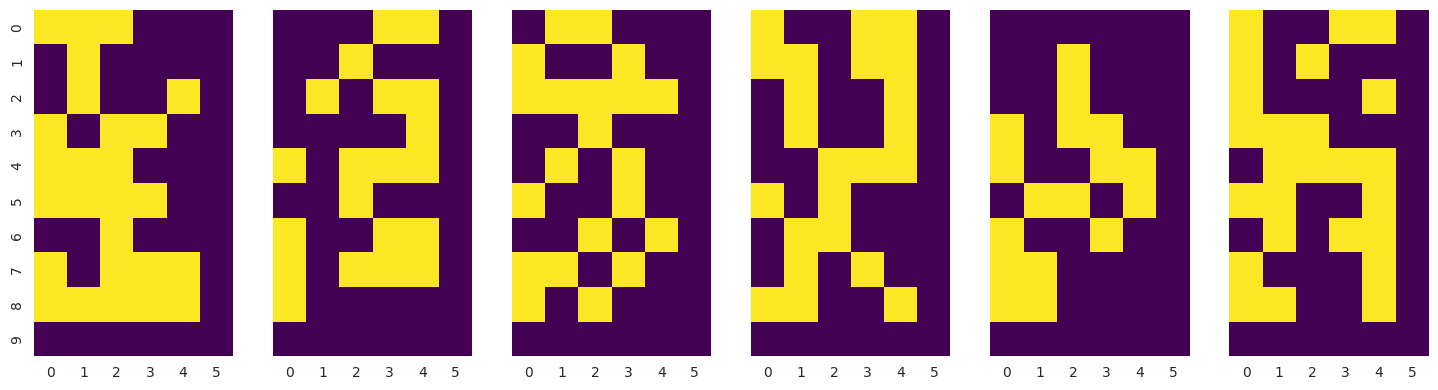

In [428]:
f, axes = plt.subplots(1, 6, figsize=(18, 4.5), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    sns.heatmap(samples[i]['param_mask'], ax=ax, cbar=False, cmap="viridis")

TypeError: list indices must be integers or slices, not str

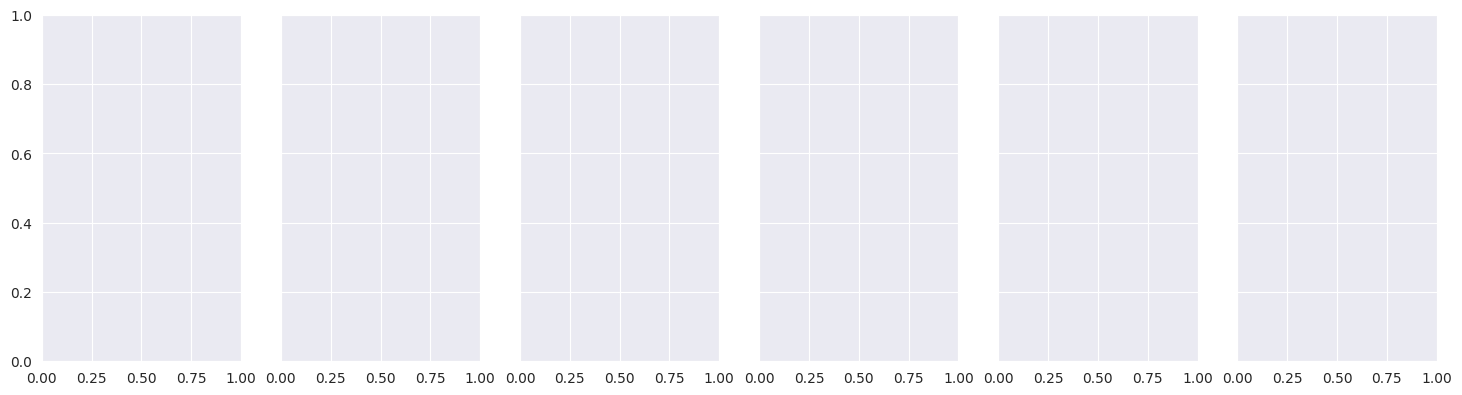

In [429]:
f, axes = plt.subplots(1, 6, figsize=(18, 4.5), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    sns.heatmap(samples['param_matrices'][i], ax=ax, cbar=False)

### RDM

In [174]:
rdm_context = ContextManager()

In [175]:
rdm_intrinsics = ["v", "a", "tau", "decay"]

In [176]:
rdm_family = NestedModelFamily(
    name="rdm",
    model=RDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=rdm_intrinsics,
)

In [177]:
num_alternatives = np.random.randint(2, 4)
correct_idx = np.random.randint(0, num_alternatives, num_obs)
print(num_alternatives, correct_idx)

3 [1 2 0 ... 2 0 0]


In [178]:
context = {
    "num_alternatives": num_alternatives,
    "correct_idx": correct_idx
}

In [179]:
out = rdm_family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    context=context,
)

33
3
3
3

3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3
3


In [182]:
cdm_intrinsics = ["v", "a", "tau", "decay"]

In [185]:
cdm_family = NestedModelFamily(
    name="cdm",
    model=CDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=cdm_intrinsics,
)

TypeError: Can't instantiate abstract class CDM with abstract method simulate

In [124]:
out = cdm_family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},  # different mask each run, reproducible
    )
)

TypeError: too many arguments: expected 7, got 8